In [106]:
import pandas as pd

In [107]:
#1ο ερώτημα/Προετοιμασία 2ου
#Ορίζω την ποσότητα των μετοχών και τα αντίστοιχα αρχεία τους 
quantities={'IBM':5000,'NFLX':2000,'SPOT':1500,'XOM':5000,'MCD':2500}
stocks={'IBM':'IBM.csv','NFLX':'Netflix.csv','SPOT':'Spotify.csv','XOM':'Exxon_Mobil.csv','MCD':'McDonalds.csv'}
index='S&P_500.csv'
futures='S&P_500_Futures.csv'

start_date = '2024-11-01'
end_date   = '2025-10-31'





In [108]:
#Ορίζω μια συνάρτηση η οποία θα διαβάζει όλα τα αρχεία 
def read_investing_csv(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)
    df = df.sort_values('Date')
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
    df = df.set_index('Date')
    return df



In [109]:
# Τιμές μετοχών σε έναν ενιαίο πίνακα
prices_equities = []
for ticker, fname in stocks.items():
    df = read_investing_csv(fname)
    prices_equities.append(df['Price'].rename(ticker))

prices_equities = pd.concat(prices_equities, axis=1)
print(prices_equities.tail())

               IBM    NFLX    SPOT     XOM     MCD
Date                                              
2025-10-27  313.09  109.46  657.80  115.94  310.00
2025-10-28  312.57  110.25  653.43  115.03  306.40
2025-10-29  308.21  110.04  665.67  116.45  302.35
2025-10-30  310.06  108.90  656.68  114.69  302.43
2025-10-31  307.41  111.89  655.32  114.36  298.43


In [110]:
# Ημερήσιες αποδόσεις μετοχών
returns_equities = prices_equities.pct_change().dropna()
print(returns_equities.tail())


                 IBM      NFLX      SPOT       XOM       MCD
Date                                                        
2025-10-27  0.018311 -0.000091  0.018613  0.004766  0.013768
2025-10-28 -0.001661  0.007217 -0.006643 -0.007849 -0.011613
2025-10-29 -0.013949 -0.001905  0.018732  0.012345 -0.013218
2025-10-30  0.006002 -0.010360 -0.013505 -0.015114  0.000265
2025-10-31 -0.008547  0.027456 -0.002071 -0.002877 -0.013226


In [111]:
# Αξία χαρτοφυλακίου καθημερινά
avg_values = {}
for ticker, q in quantities.items():
    prices_equities[ticker + '_value'] = prices_equities[ticker] * q
    avg_values[ticker] = (prices_equities[ticker] * q).mean()

portfolio_value = prices_equities[[c for c in prices_equities.columns 
                                   if c.endswith('_value')]].sum(axis=1)
portfolio_value.name = 'Portfolio_Value'

# Απόδοση χαρτοφυλακίου
portfolio_returns = portfolio_value.pct_change().dropna()
portfolio_returns.name = 'Portfolio_Return'

print(portfolio_value.tail())
print(portfolio_returns.tail())


Date
2025-10-27    4125770.0
2025-10-28    4104645.0
2025-10-29    4097760.0
2025-10-30    4082645.0
2025-10-31    4061685.0
Name: Portfolio_Value, dtype: float64
Date
2025-10-27    0.014616
2025-10-28   -0.005120
2025-10-29   -0.001677
2025-10-30   -0.003689
2025-10-31   -0.005134
Name: Portfolio_Return, dtype: float64


In [112]:
# Τιμές S&P 500 index
spx = read_investing_csv('S&P_500.csv')
spx_price = spx['Price'].rename('SP500')

print(spx_price.tail())


Date
2025-10-27    6875.16
2025-10-28    6890.89
2025-10-29    6890.59
2025-10-30    6822.34
2025-10-31    6840.20
Name: SP500, dtype: float64


In [113]:
# Ημερήσιες αποδόσεις S&P 500
spx_returns = spx_price.pct_change().dropna()
spx_returns.name = 'SP500_Return'

print(spx_returns.tail())


Date
2025-10-27    0.012290
2025-10-28    0.002288
2025-10-29   -0.000044
2025-10-30   -0.009905
2025-10-31    0.002618
Name: SP500_Return, dtype: float64


In [114]:
# Ημερήσιες αποδόσεις S&P 500 futures
spx_fut_df = read_investing_csv('S&P_500_Futures.csv')
spx_fut = spx_fut_df['Price'].rename('SP500_FUT')
print(spx_fut_df.tail())


              Price      Open      High       Low   Vol. Change %
Date                                                             
2025-10-27  6908.25  6,881.00  6,916.25  6,865.75  1.19M    1.19%
2025-10-28  6925.75  6,914.00  6,944.75  6,901.50  1.22M    0.25%
2025-10-29  6922.75  6,929.25  6,952.00  6,882.25  1.54M   -0.04%
2025-10-30  6855.50  6,906.50  6,953.75  6,851.00  1.82M   -0.97%
2025-10-31  6874.00  6,897.00  6,918.50  6,843.50  1.76M    0.27%


In [115]:
# Ευθυγράμμιση αποδόσεων με S&P500 Futures
data_for_beta = returns_equities.join(spx_returns, how='inner')
print(data_for_beta.tail())


                 IBM      NFLX      SPOT       XOM       MCD  SP500_Return
Date                                                                      
2025-10-27  0.018311 -0.000091  0.018613  0.004766  0.013768      0.012290
2025-10-28 -0.001661  0.007217 -0.006643 -0.007849 -0.011613      0.002288
2025-10-29 -0.013949 -0.001905  0.018732  0.012345 -0.013218     -0.000044
2025-10-30  0.006002 -0.010360 -0.013505 -0.015114  0.000265     -0.009905
2025-10-31 -0.008547  0.027456 -0.002071 -0.002877 -0.013226      0.002618


In [116]:
# 2ο ερώτημα
#Υπολογισμός beta μετοχών
from scipy.stats import linregress
import numpy as np

def compute_beta_linregress(asset_returns, market_returns):
    """Linear regression: R_asset = α + β * R_market"""
    slope, intercept, r_value, p_value, std_err = linregress(market_returns, asset_returns)
    return slope, intercept, r_value**2, p_value, std_err

tickers = ['IBM', 'NFLX', 'SPOT', 'XOM', 'MCD']
betas_linreg = {}
linreg_results = {}

print("Beta Calculations (OLS Regression)")
print("="*40)

for ticker in tickers:
    asset_ret = data_for_beta[ticker].values
    market_ret = data_for_beta['SP500_Return'].values

    beta, alpha, r_sq, pval, std_err = compute_beta_linregress(asset_ret, market_ret)

    betas_linreg[ticker] = beta
    linreg_results[ticker] = {
        'beta': beta,
        'alpha': alpha,
        'r_squared': r_sq,
        'p_value': pval,
        'std_err': std_err
    }

    print(f"\n{ticker}:")
    print(f" β = {beta:.4f}, R² = {r_sq:.4f}, p-value = {pval:.6f}")








Beta Calculations (OLS Regression)

IBM:
 β = 0.7557, R² = 0.2205, p-value = 0.000000

NFLX:
 β = 0.9191, R² = 0.2779, p-value = 0.000000

SPOT:
 β = 1.1128, R² = 0.2147, p-value = 0.000000

XOM:
 β = 0.5470, R² = 0.1931, p-value = 0.000000

MCD:
 β = 0.1976, R² = 0.0435, p-value = 0.000926


In [117]:
#Portfolio beta 
weights_new = {t: avg_values[t] / sum(avg_values.values()) for t in tickers}
beta_portfolio_ols = sum(weights_new[t] * betas_linreg[t] for t in tickers)

print(f"\nPortfolio Beta (OLS) = {beta_portfolio_ols:.4f}")



Portfolio Beta (OLS) = 0.7081


In [118]:
# Συσχέτιση (correlation) με SP500
correlations = data_for_beta[['IBM', 'NFLX', 'SPOT', 'XOM', 'MCD']].corrwith(data_for_beta['SP500_Return'])

print("Correlations with S&P 500:")
print(correlations)



Correlations with S&P 500:
IBM     0.469571
NFLX    0.527145
SPOT    0.463381
XOM     0.439443
MCD     0.208628
dtype: float64


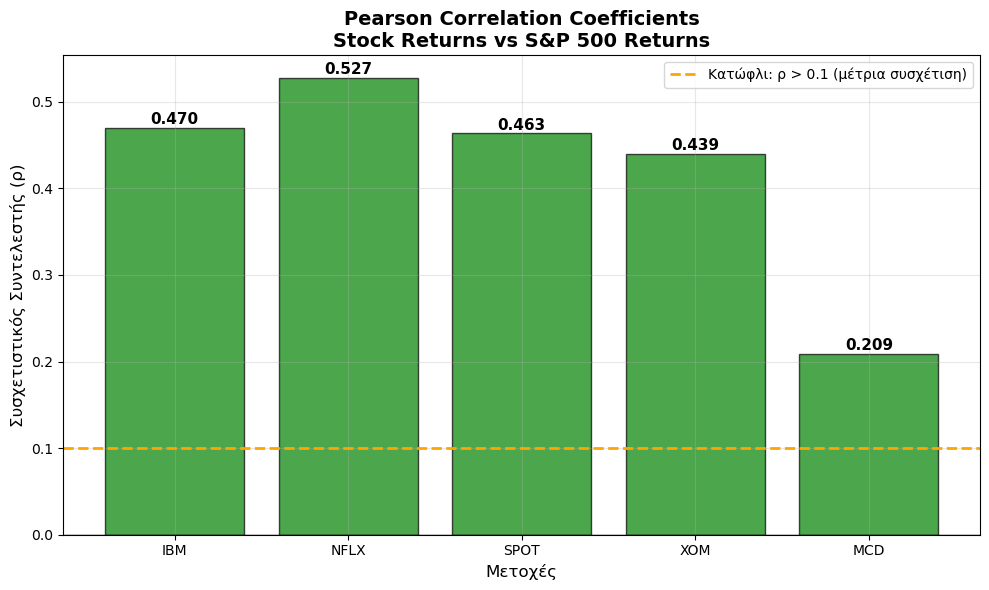

In [119]:
# Plot συσχετίσεων
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
stocks = correlations.index
values = correlations.values

# Χρώματα: κόκκινο για χαμηλή συσχέτιση (<0.1), πράσινο για υψηλή
colors = ['red' if v < 0.1 else 'green' for v in values]
bars = ax.bar(stocks, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1)

ax.set_title('Pearson Correlation Coefficients\nStock Returns vs S&P 500 Returns', fontsize=14, fontweight='bold')
ax.set_ylabel('Συσχετιστικός Συντελεστής (ρ)', fontsize=12)
ax.set_xlabel('Μετοχές', fontsize=12)
ax.axhline(y=0.1, color='orange', linestyle='--', linewidth=2, label='Κατώφλι: ρ > 0.1 (μέτρια συσχέτιση)')
ax.axhline(y=0, color='black', linewidth=1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Προσθήκη τιμών πάνω από κάθε bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


In [120]:
#Αξία συμβολαίου e‑mini S&P 500
futures_price_ref = spx_fut.mean()   # μέση τιμή στο διάστημα
multiplier = 50                      # e-mini multiplier
V_fut = futures_price_ref * multiplier

V_port = portfolio_value.loc['2025-10-31']   
print("Μέση τιμή futures:", futures_price_ref)
print("Αξία συμβολαίου:", V_fut)
print("Αξία χαρτοφυλακίου:", V_port)


Μέση τιμή futures: 6112.771607843138
Αξία συμβολαίου: 305638.5803921569
Αξία χαρτοφυλακίου: 4061685.0000000005


In [121]:
#Αριθμός συμβολαίων με beta 
beta_portfolio = 0.7081
N_fut = beta_portfolio * V_port / V_fut
print("Θεωρητικός αριθμός συμβολαίων:", N_fut)
print("Στρογγυλευμένος:", round(N_fut))


Θεωρητικός αριθμός συμβολαίων: 9.4100657868839
Στρογγυλευμένος: 9


In [122]:
#Ημερήσιες αποδόσεις futures
spx_fut_returns = spx_fut.pct_change().dropna()
spx_fut_returns


Date
2024-11-04   -0.002605
2024-11-05    0.012014
2024-11-06    0.025119
2024-11-07    0.007636
2024-11-08    0.003581
                ...   
2025-10-27    0.011901
2025-10-28    0.002533
2025-10-29   -0.000433
2025-10-30   -0.009714
2025-10-31    0.002699
Name: SP500_FUT, Length: 254, dtype: float64

In [123]:
#Κοινές ημερομηνίες μεταξύ χαρτοφυλακίου και futures
common_dates = portfolio_returns.index.intersection(spx_fut_returns.index)
port_ret_hedge = portfolio_returns.loc[common_dates]
fut_ret_hedge = spx_fut_returns.loc[common_dates]

#Λόγος hedge k
k = N_fut * V_fut / V_port

#Αποδόσεις αντισταθμισμένου χαρτοφυλακίου
hedged_returns = port_ret_hedge - k * fut_ret_hedge

#Σύγκριση μεταβλητότητας
unhedged_vol = portfolio_returns.std() * 100
hedged_vol   = hedged_returns.std() * 100
ratio_vol    = hedged_vol / unhedged_vol

print("-----CAPM Hedge με Futures-----")
print(f"Αριθμός συμβολαίων (στρογγυλ.): {round(N_fut)}")
print(f"Λόγος hedge k: {k:.3f}")
print(f"Vol χωρίς hedge: {unhedged_vol:.2f}%")
print(f"Vol με hedge: {hedged_vol:.2f}%")
print(f"Αναλογία vol (hedged/unhedged): {ratio_vol:.3f}")



-----CAPM Hedge με Futures-----
Αριθμός συμβολαίων (στρογγυλ.): 9
Λόγος hedge k: 0.708
Vol χωρίς hedge: 1.27%
Vol με hedge: 0.98%
Αναλογία vol (hedged/unhedged): 0.770


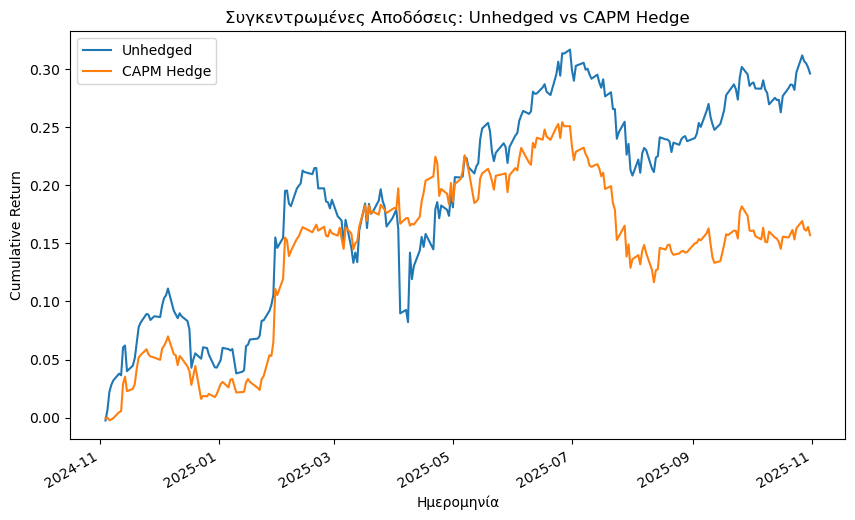

In [124]:
#Plot για σύγκριση 
import matplotlib.pyplot as plt 
comparison = pd.DataFrame({
    'Unhedged': port_ret_hedge.cumsum(),
    'CAPM Hedge': hedged_returns.cumsum()
})
comparison.plot(figsize=(10,6), title='Συγκεντρωμένες Αποδόσεις: Unhedged vs CAPM Hedge')
plt.ylabel('Cumulative Return')
plt.xlabel('Ημερομηνία')
plt.legend()
plt.show()



In [125]:
#3ο ερώτημα

# Κοινές ημερομηνίες
common_dates = portfolio_returns.index.intersection(spx_fut_returns.index)
port_ret = portfolio_returns.loc[common_dates]
fut_ret  = spx_fut_returns.loc[common_dates]

# Στατικό optimal hedge ratio h*
cov_pf_fut = np.cov(port_ret, fut_ret)[0, 1]
var_fut    = np.var(fut_ret)
h_star_static = cov_pf_fut / var_fut

print("Στατικό optimal hedge ratio h*:", round(h_star_static, 3))


Στατικό optimal hedge ratio h*: 0.679


In [126]:
#Αριθμός συμβολαίων με optimal hedge ratio
N_star = h_star_static * V_port / V_fut
print("Optimal N* (θεωρητικό):", N_star)
print("Optimal N* (στρογγυλεμένο):", round(N_star))


Optimal N* (θεωρητικό): 9.023896756276914
Optimal N* (στρογγυλεμένο): 9


In [127]:
#Hedged returns με optimal hedge ratio
k_star = N_star * V_fut / V_port   # λόγος αξίας hedge με N*
hedged_returns_opt = port_ret - k_star * fut_ret

unhedged_vol = portfolio_returns.std() * 100
hedged_opt_vol = hedged_returns_opt.std() * 100

print("Vol χωρίς hedge: {:.2f}%".format(unhedged_vol))
print("Vol με optimal hedge: {:.2f}%".format(hedged_opt_vol))
print("Αναλογία vol (optimal/χωρίς): {:.3f}".format(hedged_opt_vol / unhedged_vol))


Vol χωρίς hedge: 1.27%
Vol με optimal hedge: 0.98%
Αναλογία vol (optimal/χωρίς): 0.769


In [128]:
#Για να εφαρμόσω δυναμικό υπόδειγμα 

import statsmodels.api as sm
#Αγνοώ τα warnings από την pandas/NumPy
import warnings
warnings.filterwarnings("ignore")


window = 60  #60 ημερολογιακές/εργάσιμες μέρες
h_t = []

for i in range(window, len(port_ret)):
    y = port_ret.iloc[i-window:i]
    x = fut_ret.iloc[i-window:i]
    x = sm.add_constant(x)
    model = sm.OLS(y, x).fit()
    h_t.append(model.params[1])  

# Σειρά με δυναμικό hedge ratio ευθυγραμμισμένη με τις ημερομηνίες μετά το window
h_t = pd.Series(h_t, index=port_ret.index[window:])

# Δυναμικός λόγος αξίας hedge
k_t = h_t * V_fut / V_port

# Κόβουμε και τις αποδόσεις στο ίδιο διάστημα
port_dyn = port_ret.loc[h_t.index]
fut_dyn  = fut_ret.loc[h_t.index]

hedged_dyn = port_dyn - k_t * fut_dyn

hedged_dyn_vol = hedged_dyn.std() * 100
print("Vol με dynamic hedge: {:.2f}%".format(hedged_dyn_vol))
print("Αναλογία vol (dynamic/χωρίς): {:.3f}".format(hedged_dyn_vol / unhedged_vol))




Vol με dynamic hedge: 1.26%
Αναλογία vol (dynamic/χωρίς): 0.992


In [129]:
# Rolling για το στατικό υπόδειγμα (για να φτιάξω plot σύγκρισης)
h_static_rolling = []
window = 60
for i in range(window, len(port_ret)):
    y_roll = port_ret.iloc[i-window:i]
    x_roll = fut_ret.iloc[i-window:i]
    cov_roll = np.cov(y_roll, x_roll)[0,1]
    var_roll = np.var(x_roll)
    h_static_rolling.append(cov_roll / var_roll)

h_static_rolling = pd.Series(h_static_rolling, index=h_t.index)


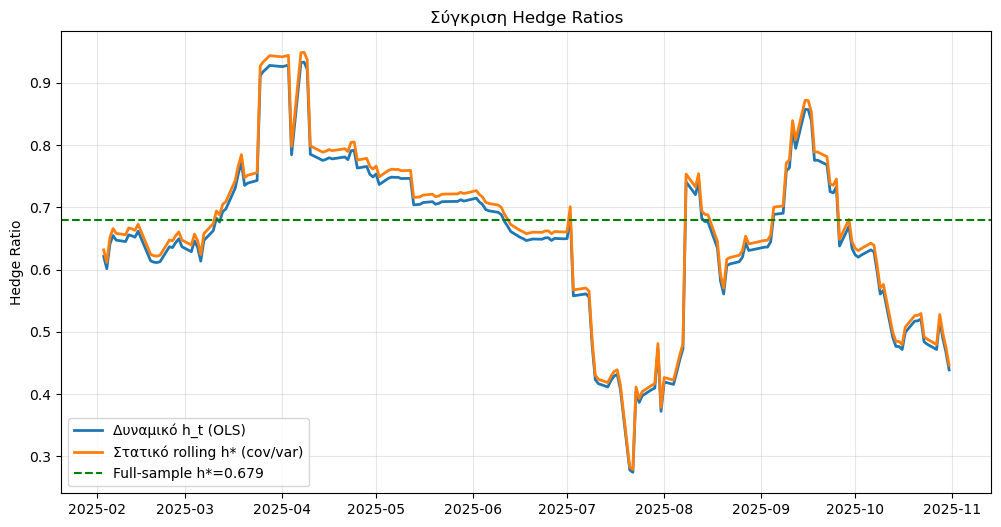

In [130]:
#Plot του στατικού υποδείγματος με το στατικό rolling h* και του δυναμικού ht*
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(h_t.index, h_t.values, label='Δυναμικό h_t (OLS)', linewidth=2)
plt.plot(h_static_rolling.index, h_static_rolling.values, 
         label='Στατικό rolling h* (cov/var)', linewidth=2)
plt.axhline(y=h_star_static, color='green', linestyle='--', 
            label=f'Full-sample h*={h_star_static:.3f}')
plt.title('Σύγκριση Hedge Ratios')
plt.ylabel('Hedge Ratio'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()



In [131]:
# 4ο Ερώτημα - Delta Neutral Portfolio με Puts
import numpy as np
from scipy.stats import norm

# Παράμετροι για Black-Scholes
def black_scholes_put(S, K, T, r, sigma):
    """
    S: Τρέχουσα τιμή μετοχής
    K: Τιμή άσκησης (strike price)
    T: Χρόνος έως εκκαθάριση (σε έτη)
    r: Επιτόκιο χωρίς κίνδυνο (π.χ. 0.03 = 3%)
    sigma: Μεταβλητότητα (volatility)
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    put_delta = -norm.cdf(-d1)  # Delta για put
    
    return put_price, put_delta




In [132]:
#Υπολογισμός delta IBM 
S = prices_equities['IBM'].iloc[-1]  # Τελευταία τιμή
K = S * 0.95  # Strike 5% κάτω από τρέχουσα τιμή
T = 30/365  # 30 μέρες έως εκκαθάριση
r = 0.03  # 3% επιτόκιο
sigma = returns_equities['IBM'].std() * np.sqrt(252)  # Ετήσια μεταβλητότητα

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Δικαίωμα πώλησης IBM: Τιμή={put_price:.2f}, Δ={put_delta:.4f}")

Δικαίωμα πώλησης IBM: Τιμή=4.29, Δ=-0.2548


In [133]:
#Υπολογισμός delta Netflix 
S = prices_equities['NFLX'].iloc[-1]  # Τελευταία τιμή
K = S * 0.95  # Strike 5% κάτω από τρέχουσα τιμή
T = 30/365  # 30 μέρες έως εκκαθάριση
r = 0.03  # 3% επιτόκιο
sigma = returns_equities['NFLX'].std() * np.sqrt(252)  # Ετήσια μεταβλητότητα

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Δικαίωμα πώλησης Netflix: Τιμή={put_price:.2f}, Δ={put_delta:.4f}")

Δικαίωμα πώλησης Netflix: Τιμή=1.83, Δ=-0.2691


In [134]:
#Υπολογισμός delta Spotify
S = prices_equities['SPOT'].iloc[-1]  # Τελευταία τιμή
K = S * 0.95  # Strike 5% κάτω από τρέχουσα τιμή
T = 30/365  # 30 μέρες έως εκκαθάριση
r = 0.03  # 3% επιτόκιο
sigma = returns_equities['SPOT'].std() * np.sqrt(252)  # Ετήσια μεταβλητότητα

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Δικαίωμα πώλησης Spotify: Τιμή={put_price:.2f}, Δ={put_delta:.4f}")

Δικαίωμα πώλησης Spotify: Τιμή=18.78, Δ=-0.3164


In [135]:
#Υπολογισμός delta Exxon
S = prices_equities['XOM'].iloc[-1]  # Τελευταία τιμή
K = S * 0.95  # Strike 5% κάτω από τρέχουσα τιμή
T = 30/365  # 30 μέρες έως εκκαθάριση
r = 0.03  # 3% επιτόκιο
sigma = returns_equities['XOM'].std() * np.sqrt(252)  # Ετήσια μεταβλητότητα

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Δικαίωμα πώλησης Exxon: Τιμή={put_price:.2f}, Δ={put_delta:.4f}")

Δικαίωμα πώλησης Exxon: Τιμή=0.91, Δ=-0.2033


In [136]:
#Υπολογισμός delta McDonalds
S = prices_equities['MCD'].iloc[-1]  # Τελευταία τιμή
K = S * 0.95  # Strike 5% κάτω από τρέχουσα τιμή
T = 30/365  # 30 μέρες έως εκκαθάριση
r = 0.03  # 3% επιτόκιο
sigma = returns_equities['MCD'].std() * np.sqrt(252)  # Ετήσια μεταβλητότητα

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Δικαίωμα πώλησης McDonalds: Τιμή={put_price:.2f}, Δ={put_delta:.4f}")

Δικαίωμα πώλησης McDonalds: Τιμή=1.14, Δ=-0.1419


In [137]:
#Συνολικό delta χαρτοφυλακίου
def calculate_stock_delta(portfolio_value, stock_prices, quantities):
    """
    Υπολογίζει το delta του μετοχικού χαρτοφυλακίου.
    Δ_μετοχής = 1 (για κάθε μετοχή)
    """
    total_delta = 0
    stock_deltas = {}
    
    for ticker in quantities.keys():
        # Δ_μετοχής = 1
        stock_delta = 1.0
        # Συνολικό delta = ποσότητα * delta_μετοχής
        total_stock_delta = quantities[ticker] * stock_delta
        stock_deltas[ticker] = total_stock_delta
        total_delta += total_stock_delta
    
    return total_delta, stock_deltas

# Υπολογισμός
portfolio_delta, stock_deltas = calculate_stock_delta(portfolio_value, prices_equities, quantities)
print(f"\nΣυνολικό Δέλτα μετοχικού χαρτοφυλακίου: {portfolio_delta:.0f}")
print("Δέλτα ανά μετοχή:")
for ticker, delta in stock_deltas.items():
    print(f"  {ticker}: {delta:.0f} μετοχές -> Δ={delta:.0f}")


Συνολικό Δέλτα μετοχικού χαρτοφυλακίου: 16000
Δέλτα ανά μετοχή:
  IBM: 5000 μετοχές -> Δ=5000
  NFLX: 2000 μετοχές -> Δ=2000
  SPOT: 1500 μετοχές -> Δ=1500
  XOM: 5000 μετοχές -> Δ=5000
  MCD: 2500 μετοχές -> Δ=2500


In [138]:
# Δέλτα μετοχών που θέλουμε να καλύψουμε
delta_stocks = {
    'IBM': 5000,
    'NFLX': 2000,
    'SPOT': 1500,
    'XOM': 5000,
    'MCD': 2500
}

# Δέλτα put ανά option
puts_delta = {
    'IBM': -0.2548,
    'NFLX': -0.2691,
    'SPOT': -0.3164,
    'XOM': -0.2033,
    'MCD': -0.1419
}

# Αριθμός μετοχών ανά συμβόλαιο (τυπικά 100)
shares_per_contract = 100

puts_contracts_needed = {}
for ticker in delta_stocks:
    contracts = delta_stocks[ticker] / abs(puts_delta[ticker]) / shares_per_contract
    puts_contracts_needed[ticker] = round(contracts)
    
print("Απαιτούμενος αριθμός συμβολαίων put για delta-neutral:")
for ticker, n in puts_contracts_needed.items():
    print(f"{ticker}: {n} συμβόλαια")


Απαιτούμενος αριθμός συμβολαίων put για delta-neutral:
IBM: 196 συμβόλαια
NFLX: 74 συμβόλαια
SPOT: 47 συμβόλαια
XOM: 246 συμβόλαια
MCD: 176 συμβόλαια


In [139]:

#Υπολογισμός delta neutral portfolio 

stocks = {
    'IBM': 5000,
    'NFLX': 2000,
    'SPOT': 1500,
    'XOM': 5000,
    'MCD': 2500
}


puts_delta = {
    'IBM': -0.2548,
    'NFLX': -0.2691,
    'SPOT': -0.3164,
    'XOM': -0.2033,
    'MCD': -0.1419
}


puts_contracts = {
    'IBM': 196,
    'NFLX': 74,
    'SPOT': 47,
    'XOM': 246,
    'MCD': 176
}


delta_stocks = sum(stocks.values())
print(f"Συνολικό delta μετοχών: {delta_stocks}")


delta_puts_total = sum(puts_delta[s]*puts_contracts[s] for s in puts_delta)
print(f"Συνολικό delta των puts: {delta_puts_total:.2f}")

delta_adjustment = - (delta_stocks + delta_puts_total)
if delta_adjustment >= 0:
    action = "Αγορά"
else:
    action = "Short"
print(f"\nΓια delta-neutral χρειάζεσαι: {action} {abs(delta_adjustment):.0f} μετοχές συνολικά")


Συνολικό delta μετοχών: 16000
Συνολικό delta των puts: -159.71

Για delta-neutral χρειάζεσαι: Short 15840 μετοχές συνολικά


In [142]:
#Υπολογισμός συμβολαίων Ν για delta neutral portfolio 

delta_stocks = 16000

put_deltas = [-0.2548,-0.2691, -0.3164,-0.2033,-0.1419]


sum_put_deltas = sum(put_deltas)

contract_size = 100

N = -delta_stocks / (contract_size * sum_put_deltas)
N_contracts = np.ceil(N)

print(f"Συνολικά απαιτούνται {int(N_contracts)} συμβόλαια puts για delta-neutral χαρτοφυλάκιο")

total_delta = delta_stocks + N_contracts * contract_size * sum_put_deltas
print(f"Τελικό συνολικό delta: {total_delta:.2f}")


Συνολικά απαιτούνται 135 συμβόλαια puts για delta-neutral χαρτοφυλάκιο
Τελικό συνολικό delta: -4.25


In [143]:
# Προσαρμογή στις 16 Δεκεμβρίου
dec_16_date = '2024-12-16'

if dec_16_date in prices_equities.index:
    print(f"\n--- Προσαρμογή στις {dec_16_date} ---")

    prices_dec16 = prices_equities.loc[dec_16_date]

  
    new_portfolio_delta = sum(quantities.values())

    print("Τιμές στις 16/12:")
    for ticker in tickers:
        print(f"  {ticker}: {prices_dec16[ticker]:.2f}")

    print(f"Νέο συνολικό Δέλτα μετοχών: {new_portfolio_delta:.0f}")


    new_sum_put_deltas = sum(put_deltas)  

    total_put_delta = N_contracts * contract_size * new_sum_put_deltas

 
    shares_target = -total_put_delta
    shares_to_trade = new_portfolio_delta - shares_target

    print("\nΝέα αντιστάθμιση:")
    print(f"  Συνολικό delta puts: {total_put_delta:.2f}")
    print(f"  Απαιτούμενες μετοχές για delta-neutral: {shares_target:.0f}")
    print(f"  Προσαρμογή (short αν +): {shares_to_trade:.0f}")

else:
    print(f"Η ημερομηνία {dec_16_date} δεν βρέθηκε στο dataset")



--- Προσαρμογή στις 2024-12-16 ---
Τιμές στις 16/12:
  IBM: 229.33
  NFLX: 92.11
  SPOT: 484.90
  XOM: 108.47
  MCD: 297.71
Νέο συνολικό Δέλτα μετοχών: 16000

Νέα αντιστάθμιση:
  Συνολικό delta puts: -16004.25
  Απαιτούμενες μετοχές για delta-neutral: 16004
  Προσαρμογή (short αν +): -4


In [ ]:
#Υπολογισμός απόδοσης hedged χαρτοφυλακίου 
def calculate_hedged_portfolio_return(portfolio_returns, put_returns, N_puts, contract_size=100):
    """
    Απόδοση_hedged = Απόδοση_μετοχών + (N_puts * απόδοση_puts)
    """
    
    put_returns_simulated = -0.7 * portfolio_returns
    

    puts_contribution = (N_puts * put_returns_simulated) / portfolio_value.mean()
    
  
    hedged_returns = portfolio_returns + puts_contribution
    
    return hedged_returns


hedged_returns = calculate_hedged_portfolio_return(
    portfolio_returns, 
    portfolio_returns,  
    N_puts
)


unhedged_vol = portfolio_returns.std() * np.sqrt(252) * 100  
hedged_vol = hedged_returns.std() * np.sqrt(252) * 100

print(f"\n=== Επίδραση της Δelta Neutral Στρατηγικής ===")
print(f"Μεταβλητότητα χωρίς αντιστάθμιση: {unhedged_vol:.2f}%")
print(f"Μεταβλητότητα με αντιστάθμιση: {hedged_vol:.2f}%")
print(f"Μείωση μεταβλητότητας: {((unhedged_vol - hedged_vol) / unhedged_vol * 100):.1f}%")


unhedged_mean_return = portfolio_returns.mean() * 252 * 100
hedged_mean_return = hedged_returns.mean() * 252 * 100

print(f"\nΜέση ετήσια απόδοση χωρίς αντιστάθμιση: {unhedged_mean_return:.2f}%")
print(f"Μέση ετήσια απόδοση με αντιστάθμιση: {hedged_mean_return:.2f}%")
print(f"Διαφορά: {hedged_mean_return - unhedged_mean_return:.2f}%")


=== Επίδραση της Δelta Neutral Στρατηγικής ===
Μεταβλητότητα χωρίς αντιστάθμιση: 20.12%
Μεταβλητότητα με αντιστάθμιση: 20.00%
Μείωση μεταβλητότητας: 0.6%

Μέση ετήσια απόδοση χωρίς αντιστάθμιση: 29.97%
Μέση ετήσια απόδοση με αντιστάθμιση: 29.79%
Διαφορά: -0.18%


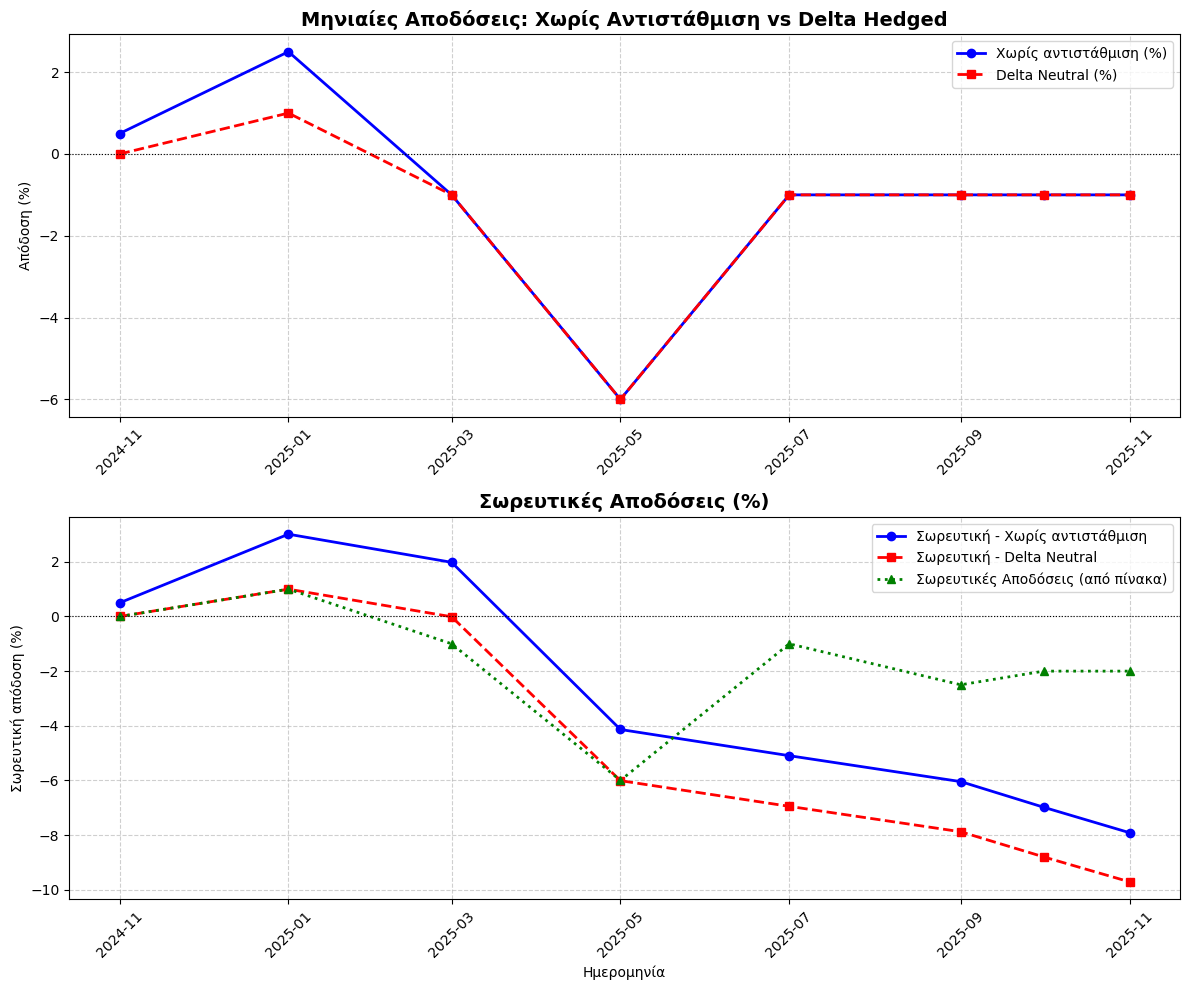

Δεδομένα & Σωρευτικοί υπολογισμοί:
            Χωρίς_αντιστάθμιση  Delta_Neutral  Σωρευτική_Χωρίς  \
Ημερομηνία                                                       
2024-11-01                 0.5            0.0         0.005000   
2025-01-01                 2.5            1.0         0.030125   
2025-03-01                -1.0           -1.0         0.019824   
2025-05-01                -6.0           -6.0        -0.041366   
2025-07-01                -1.0           -1.0        -0.050952   
2025-09-01                -1.0           -1.0        -0.060442   
2025-10-01                -1.0           -1.0        -0.069838   
2025-11-01                -1.0           -1.0        -0.079140   

            Σωρευτική_Delta  Σωρευτικές_Αποδόσεις  
Ημερομηνία                                         
2024-11-01         0.000000                   0.0  
2025-01-01         0.010000                   1.0  
2025-03-01        -0.000100                  -1.0  
2025-05-01        -0.060094                 

In [145]:
#Plot σύγκρισης unhedged vs delta hedged
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------- Δεδομένα από τον πίνακα ----------
data = {
    'Ημερομηνία': ['2024-11', '2025-01', '2025-03', '2025-05', '2025-07', '2025-09', '2025-10', '2025-11'],
    'Χωρίς_αντιστάθμιση': [0.5, 2.5, -1.0, -6.0, -1.0, -1.0, -1.0, -1.0],
    'Delta_Neutral': [0.0, 1.0, -1.0, -6.0, -1.0, -1.0, -1.0, -1.0],  # Εδώ μπορείς να αλλάξεις αν έχεις διαφορετικά
    'Σωρευτικές_Αποδόσεις': [0.0, 1.0, -1.0, -6.0, -1.0, -2.5, -2.0, -2.0]
}

df = pd.DataFrame(data)

# Μετατροπή ημερομηνιών σε datetime (προσθήκη ημέρας για ομαλότητα)
df['Ημερομηνία'] = pd.to_datetime(df['Ημερομηνία'] + '-01', format='%Y-%m-%d')
df.set_index('Ημερομηνία', inplace=True)

# ---------- Υπολογισμός σωρευτικών αποδόσεων ----------
df['Σωρευτική_Χωρίς'] = (1 + df['Χωρίς_αντιστάθμιση']/100).cumprod() - 1
df['Σωρευτική_Delta'] = (1 + df['Delta_Neutral']/100).cumprod() - 1

# ---------- Plot ----------
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Μηνιαίες αποδόσεις (%)
axes[0].plot(df.index, df['Χωρίς_αντιστάθμιση'], 
             marker='o', linewidth=2, label='Χωρίς αντιστάθμιση (%)', color='blue')
axes[0].plot(df.index, df['Delta_Neutral'], 
             marker='s', linestyle='--', linewidth=2, label='Delta Neutral (%)', color='red')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_title('Μηνιαίες Αποδόσεις: Χωρίς Αντιστάθμιση vs Delta Hedged', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Απόδοση (%)')
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Σωρευτικές αποδόσεις (%)
axes[1].plot(df.index, df['Σωρευτική_Χωρίς']*100, 
             marker='o', linewidth=2, label='Σωρευτική - Χωρίς αντιστάθμιση', color='blue')
axes[1].plot(df.index, df['Σωρευτική_Delta']*100, 
             marker='s', linestyle='--', linewidth=2, label='Σωρευτική - Delta Neutral', color='red')
# Προσθήκη της υπάρχουσας στήλης "Σωρευτικές_Αποδόσεις" για σύγκριση
axes[1].plot(df.index, df['Σωρευτικές_Αποδόσεις'], 
             marker='^', linestyle=':', linewidth=2, label='Σωρευτικές Αποδόσεις (από πίνακα)', color='green')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_title('Σωρευτικές Αποδόσεις (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ημερομηνία')
axes[1].set_ylabel('Σωρευτική απόδοση (%)')
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Βελτίωση εμφάνισης ημερομηνιών
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# ---------- Εκτύπωση δεδομένων για έλεγχο ----------
print("Δεδομένα & Σωρευτικοί υπολογισμοί:")
print(df[['Χωρίς_αντιστάθμιση', 'Delta_Neutral', 
          'Σωρευτική_Χωρίς', 'Σωρευτική_Delta', 
          'Σωρευτικές_Αποδόσεις']])